In [1]:
library(ggplot2)
library(tidyverse)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
data<-read.csv(paste0(indir,'/PCC_df_le2_se50.csv'), row.names=1)
head(data);dim(data)

,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,PCC_5hmCG_RNA
,<chr>,<int>,<chr>,<dbl>,<dbl>
0,chr1,463,ENSMUSG00000002459.17,-0.20726372,-0.15418849
1,chr1,641,ENSMUSG00000033740.17,0.08479841,-0.30560963
2,chr1,1024,ENSMUSG00000042501.12,-0.27949825,-0.30778747
4,chr1,1083,ENSMUSG00000048960.13,0.38296159,0.04769515
6,chr1,1198,ENSMUSG00000057715.13,0.45005256,0.58763418
7,chr1,1213,ENSMUSG00000057715.13,-0.27946062,0.53898734


[1] 17381     5

In [5]:
options(repr.plot.width=36/25.4,repr.plot.height=36/25.4,repr.plot.res=400)

In [45]:
data$'group'=sapply(data$'PCC_3C_RNA'>0.5, function(a){if(a){return('PCC(3C interaction, RNA)>0.5')}else{return('others')}})
# Change the order of the factor levels
data$'group' <- factor(data$'group', levels = c('PCC(3C interaction, RNA)>0.5', 'others'))

p<-ggplot(data, aes(x = PCC_5hmCG_RNA, group = group, color = group,alpha=group)) +
geom_density(aes(alpha=group)) +
geom_area(stat = "density", aes(y = ..density..,alpha=group),fill="#FFA500" ,position = "identity")+ # 使用geom_area来模拟阴影  
scale_alpha_manual(values = c('PCC(3C interaction, RNA)>0.5' = 0.3, 'others' = 0.01)) +# 单独设置每组的透明度  
scale_color_manual(values = c('PCC(3C interaction, RNA)>0.5' = "#DB9980", 'others' = "#97a0a6"))+
scale_x_continuous(breaks=c(-1,-0.5,0,0.5,1),limit=c(-1,1))+
# scale_y_continuous(breaks = seq(from = 0, to = 85, by = 20), limits = c(0, 85))+
# geom_vline(xintercept = quantiles, linetype = "dashed", color = "#c9d6df",size=0.5) +
labs(x ="PCC(5hmCG%, RNA)" ,y="Density")+
geom_text(aes(label='KL = 0.194',family="ArialMT",fontface='plain'),x=-0.5,y=1.3,size=2,color='black')+
theme_bw()+
theme(legend.position="none",
legend.title = element_text(size = 6),  # Change legend title size
legend.text = element_text(size = 6),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=6,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=6,family="ArialMT"),
axis.title.y = element_text(color="black", size=6,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())


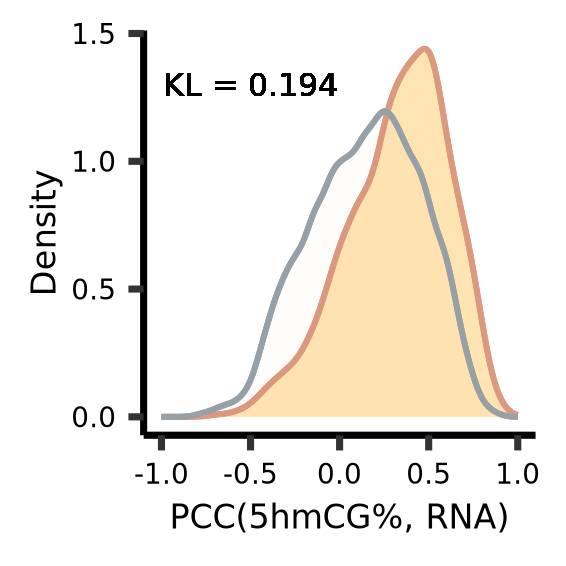

In [46]:
p

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/05_PCC(5hmCG,RNA)_density_plot.pdf', width=36/25.4,height=36/25.4, family="ArialMT")
print(p)
dev.off()

pdf 
  2